# Imports

In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.linalg as la
import scipy.stats as stats
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from joblib import Parallel, delayed
from numpy.lib.stride_tricks import sliding_window_view

warnings.filterwarnings("ignore")

# Settings

In [2]:
FILTER_OUTPUT_DIR = "crypto_universe_output"

PRVM_OUTPUT_DIR = "crypto_prvm_output"
Path(PRVM_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

LOG_PRICE_PATH = f"{FILTER_OUTPUT_DIR}/log_price_2023_2025_top200.parquet"

START_DATE = "2023-01-01"
END_DATE = "2025-12-31"

DO_PSD_PROJECTION = True

# Log price data loading

In [3]:
log_price_panel = pd.read_parquet(LOG_PRICE_PATH)

log_price_panel.index = pd.to_datetime(log_price_panel.index)
log_price_panel = log_price_panel.sort_index()

# 기간 제한
log_price_panel = log_price_panel.loc[START_DATE:END_DATE]

print("log_price_panel shape:", log_price_panel.shape)
print("index type:", type(log_price_panel.index))
print("start:", log_price_panel.index.min())
print("end  :", log_price_panel.index.max())

display(log_price_panel.head())
display(log_price_panel.tail())

print("Total NaN cells:", log_price_panel.isna().sum().sum())

log_price_panel shape: (1576800, 200)
index type: <class 'pandas.DatetimeIndex'>
start: 2023-01-01 00:00:00
end  : 2025-12-31 23:59:00


,BTCUSDT,ETHUSDT,GMTUSDT,BNBUSDT,LUNAUSDT,SOLUSDT,XRPUSDT,DOGEUSDT,APEUSDT,SHIBUSDT,...,VTHOUSDT,ONGUSDT,OXTUSDT,AMPUSDT,AVAUSDT,WANUSDT,ALCXUSDT,DFUSDT,OMUSDT,XNOUSDT
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,9.713758,7.086847,-1.468372,5.506550,0.231905,2.300583,-1.081755,-2.654699,1.291159,-11.724882,...,-7.008681,-1.546933,-2.695628,-5.792614,-0.638659,-1.714798,2.617396,-3.26492,-3.568433,-0.450986
2023-01-01 00:01:00,9.713495,7.086813,-1.468372,5.506550,0.233411,2.303585,-1.081755,-2.654557,1.290609,-11.724882,...,-7.007576,-1.546933,-2.695628,-5.792614,-0.638659,-1.714243,2.617396,-3.26492,-3.568433,-0.450986
2023-01-01 00:02:00,9.713321,7.086613,-1.470111,5.506144,0.231826,2.303585,-1.082641,-2.655837,1.290609,-11.724882,...,-7.007576,-1.546933,-2.695628,-5.792614,-0.638659,-1.712024,2.617396,-3.26492,-3.568433,-0.450986
2023-01-01 00:03:00,9.713153,7.086587,-1.469676,5.505332,0.231826,2.303585,-1.082641,-2.656692,1.290334,-11.724882,...,-7.007576,-1.550226,-2.695628,-5.792614,-0.638659,-1.712024,2.617396,-3.26492,-3.568433,-0.450986
2023-01-01 00:04:00,9.713258,7.087006,-1.467071,5.506144,0.231270,2.302585,-1.082936,-2.656407,1.289783,-11.723646,...,-7.007576,-1.550226,-2.697110,-5.792614,-0.638659,-1.712024,2.617396,-3.26492,-3.568433,-0.454130


,BTCUSDT,ETHUSDT,GMTUSDT,BNBUSDT,LUNAUSDT,SOLUSDT,XRPUSDT,DOGEUSDT,APEUSDT,SHIBUSDT,...,VTHOUSDT,ONGUSDT,OXTUSDT,AMPUSDT,AVAUSDT,WANUSDT,ALCXUSDT,DFUSDT,OMUSDT,XNOUSDT
datetime,,,,,,,,,,,,,,,,,,,,,
2025-12-31 23:55:00,11.381136,7.996930,-4.190415,6.762036,-2.350725,4.825670,0.611503,-2.141572,-1.627093,-11.881095,...,-7.192774,-2.475749,-3.79424,-6.285030,-1.276902,-2.632479,2.008214,-4.478538,-2.672201,-0.372514
2025-12-31 23:56:00,11.381167,7.997266,-4.190415,6.762313,-2.349677,4.825991,0.611612,-2.141232,-1.627093,-11.881095,...,-7.192774,-2.475749,-3.79424,-6.276484,-1.276902,-2.635265,2.008214,-4.480301,-2.672201,-0.372514
2025-12-31 23:57:00,11.381026,7.996869,-4.189755,6.762163,-2.351775,4.825429,0.610961,-2.141998,-1.627602,-11.882541,...,-7.192774,-2.476938,-3.79424,-6.277016,-1.276902,-2.632479,2.010895,-4.482068,-2.672201,-0.372514
2025-12-31 23:58:00,11.381026,7.996872,-4.191076,6.762105,-2.351775,4.825349,0.611069,-2.141742,-1.627602,-11.882541,...,-7.192774,-2.475749,-3.79424,-6.273297,-1.276902,-2.632479,2.010895,-4.483838,-2.672201,-0.372514
2025-12-31 23:59:00,11.381086,7.996869,-4.191076,6.761920,-2.350725,4.825510,0.611015,-2.141572,-1.627602,-11.882541,...,-7.192774,-2.476938,-3.79424,-6.273297,-1.279056,-2.632479,2.010895,-4.482953,-2.670754,-0.373966


Total NaN cells: 0


In [4]:
log_price_panel.isnull().sum().sum()

np.int64(0)

In [5]:
# 하루별 데이터 확인
daily_counts = (
    log_price_panel
    .groupby(log_price_panel.index.normalize())
    .size()
    .rename("n_minutes")
    .reset_index()
    .rename(columns={"index": "date"})
)

display(daily_counts.head())
display(daily_counts.tail())

print(daily_counts["n_minutes"].describe())

,datetime,n_minutes
0,2023-01-01,1440
1,2023-01-02,1440
2,2023-01-03,1440
3,2023-01-04,1440
4,2023-01-05,1440


,datetime,n_minutes
1090,2025-12-27,1440
1091,2025-12-28,1440
1092,2025-12-29,1440
1093,2025-12-30,1440
1094,2025-12-31,1440


count    1095.0
mean     1440.0
std         0.0
min      1440.0
25%      1440.0
50%      1440.0
75%      1440.0
max      1440.0
Name: n_minutes, dtype: float64


# PRVM function

In [6]:
def g_wedge(x: np.ndarray) -> np.ndarray:

    return np.minimum(x, 1.0 - x)

def project_to_psd_spectral(A: np.ndarray, eps: float = 1e-10) -> np.ndarray:

    A_sym = (A + A.T) / 2.0
    w, V = la.eigh(A_sym)
    w = np.maximum(w, eps)
    return (V * w) @ V.T

def prvm_one_day(
    log_price_day: pd.DataFrame,
    alpha_u: float = 0.47,
    c0: float = 4.0,
    do_psd_projection: bool = True,
):
    # Basic input
    Y = log_price_day.values.astype(np.float64)

    if np.isnan(Y).any():
        raise ValueError("log_price_day contains NaN. Clean the data before PRVM.")

    n_obs, p = Y.shape
    m = n_obs - 1

    if m < 20:
        raise ValueError(f"Too few intraday observations: n_obs={n_obs}, m={m}")

    K = int(np.floor(np.sqrt(m)))

    if K < 2:
        raise ValueError(f"K is too small: K={K}")

    dY = np.diff(Y, axis=0)

    l_vec = np.arange(1, K)
    g_vals = g_wedge(l_vec / K)

    L = m - K + 1

    if L <= K:
        raise ValueError(f"L={L} <= K={K}. Not enough observations for threshold.")

    Ybar = np.zeros((L, p), dtype=np.float64)

    for k in range(L):
        Ybar[k] = np.sum(dY[k:k + K - 1] * g_vals[:, None], axis=0)

    prod = np.abs(Ybar[:L - K]) * np.abs(Ybar[K:])

    scale_T = (m / (m - 2 * K + 1)) * (np.pi / (2 * K))
    T_hat = scale_T * np.sum(prod, axis=0)
    T_hat = np.maximum(T_hat, 1e-18)

    u = c0 * np.sqrt(T_hat) * ((K / m) ** alpha_u)

    mask = (np.abs(Ybar) <= u).astype(np.float64)
    Ybar_masked = Ybar * mask

    grid = np.arange(0, K + 1) / K
    w_sq = (g_wedge(grid)[1:] - g_wedge(grid)[:-1]) ** 2

    Bias_trunc_sum = np.zeros((p, p), dtype=np.float64)
    Bias_untrunc_sum = np.zeros((p, p), dtype=np.float64)

    for k in range(L):
        dY_seg = dY[k:k + K]

        Yhat_local = (dY_seg.T * w_sq) @ dY_seg

        Bias_untrunc_sum += Yhat_local

        mk = mask[k]
        Bias_trunc_sum += np.outer(mk, mk) * Yhat_local

    Main_untrunc = Ybar.T @ Ybar
    Main_trunc = Ybar_masked.T @ Ybar_masked

    psi = 1.0 / 12.0

    Gamma_untrunc_raw = (1.0 / (psi * K)) * (
        Main_untrunc - 0.5 * Bias_untrunc_sum
    )

    Gamma_trunc_raw = (1.0 / (psi * K)) * (
        Main_trunc - 0.5 * Bias_trunc_sum
    )

    Gamma_untrunc_raw = (Gamma_untrunc_raw + Gamma_untrunc_raw.T) / 2.0
    Gamma_trunc_raw = (Gamma_trunc_raw + Gamma_trunc_raw.T) / 2.0

    JV_raw = Gamma_untrunc_raw - Gamma_trunc_raw
    JV_raw = (JV_raw + JV_raw.T) / 2.0

    if do_psd_projection:
        Gamma_untrunc_psd = project_to_psd_spectral(Gamma_untrunc_raw)
        Gamma_trunc_psd = project_to_psd_spectral(Gamma_trunc_raw)
    else:
        Gamma_untrunc_psd = Gamma_untrunc_raw
        Gamma_trunc_psd = Gamma_trunc_raw

    return {
        "Gamma_trunc_raw": Gamma_trunc_raw,
        "Gamma_untrunc_raw": Gamma_untrunc_raw,
        "JV_raw": JV_raw,
        "Gamma_trunc_psd": Gamma_trunc_psd,
        "Gamma_untrunc_psd": Gamma_untrunc_psd,
    }

In [7]:
# Build Gamma_list from log_price_panel, 전체 날짜에 대해 PRVM 계산

def build_Gamma_list_from_log_price(
    log_price: pd.DataFrame,
    do_psd_projection: bool = True,
    min_obs_per_day: int = 20,
):
    Gamma_trunc_raw_list = []
    Gamma_untrunc_raw_list = []
    JV_raw_list = []

    Gamma_trunc_psd_list = []
    Gamma_untrunc_psd_list = []

    days = []

    grouped = log_price.groupby(log_price.index.normalize(), sort=True)

    print(f"Generating PRVM matrices for {len(grouped)} days...")

    skipped = []

    for day, df_day in tqdm(grouped):
        df_day = df_day.sort_index()
        df_day = df_day.dropna(axis=0, how="any")

        if len(df_day) < min_obs_per_day:
            skipped.append((pd.Timestamp(day), len(df_day), "too few observations"))
            continue

        try:
            out = prvm_one_day(
                log_price_day=df_day,
                do_psd_projection=do_psd_projection,
            )

            Gamma_trunc_raw_list.append(out["Gamma_trunc_raw"])
            Gamma_untrunc_raw_list.append(out["Gamma_untrunc_raw"])
            JV_raw_list.append(out["JV_raw"])

            Gamma_trunc_psd_list.append(out["Gamma_trunc_psd"])
            Gamma_untrunc_psd_list.append(out["Gamma_untrunc_psd"])

            days.append(pd.Timestamp(day))

        except Exception as e:
            skipped.append((pd.Timestamp(day), len(df_day), str(e)))
            continue

    skipped_df = pd.DataFrame(
        skipped,
        columns=["date", "n_obs", "reason"]
    )

    return (
        Gamma_trunc_raw_list,
        Gamma_untrunc_raw_list,
        JV_raw_list,
        Gamma_trunc_psd_list,
        Gamma_untrunc_psd_list,
        days,
        skipped_df,
    )

# PRVM execution

In [8]:
# Gamma_list, Gamma_untrunc_list, JV_list, days, skipped_df = build_Gamma_list_from_log_price(
#     log_price=log_price_panel,
#     do_psd_projection=DO_PSD_PROJECTION,
#     min_obs_per_day=20,
# )

# print("Number of PRVM days:", len(Gamma_list))
# print("Number of skipped days:", len(skipped_df))

# if len(Gamma_list) > 0:
#     print("One Gamma shape:", Gamma_list[0].shape)
#     print("First day:", days[0])
#     print("Last day :", days[-1])

# display(skipped_df.head())

In [9]:
(Gamma_trunc_raw_list, Gamma_untrunc_raw_list,JV_raw_list,
    Gamma_trunc_psd_list, Gamma_untrunc_psd_list, days, skipped_df,
) = build_Gamma_list_from_log_price(
    log_price=log_price_panel,
    do_psd_projection=DO_PSD_PROJECTION,
    min_obs_per_day=20,
)

display(skipped_df.head())

Generating PRVM matrices for 1095 days...


100%|██████████| 1095/1095 [05:08<00:00,  3.55it/s]


,date,n_obs,reason


In [10]:
# Numpy 변환

Gamma_trunc_raw_array = np.stack(Gamma_trunc_raw_list, axis=0)
Gamma_untrunc_raw_array = np.stack(Gamma_untrunc_raw_list, axis=0)
JV_raw_array = np.stack(JV_raw_list, axis=0)

Gamma_trunc_psd_array = np.stack(Gamma_trunc_psd_list, axis=0)
Gamma_untrunc_psd_array = np.stack(Gamma_untrunc_psd_list, axis=0)

days_array = np.array(days, dtype="datetime64[D]")

# Save PRVM

In [11]:
save_prvm_path = os.path.join(
    PRVM_OUTPUT_DIR,
    "prvm_gamma_jv_2023_2025_top200.npz" # (day, 200, 200) 3차원 배열
)

np.savez_compressed(
    save_prvm_path,
    Gamma_trunc_raw=Gamma_trunc_raw_array,
    Gamma_untrunc_raw=Gamma_untrunc_raw_array,
    JV_raw=JV_raw_array,
    Gamma_trunc_psd=Gamma_trunc_psd_array,
    Gamma_untrunc_psd=Gamma_untrunc_psd_array,
    days=days_array,
)

print(f"Saved PRVM result: {save_prvm_path}")

Saved PRVM result: crypto_prvm_output\prvm_gamma_jv_2023_2025_top200.npz


In [12]:
# # 불러올 때
# loaded = np.load(
#     f"{PRVM_OUTPUT_DIR}/prvm_gamma_jv_2023_2025_top200.npz",
#     allow_pickle=True,
# )

# Gamma_trunc_raw_array = loaded["Gamma_trunc_raw"]
# Gamma_untrunc_raw_array = loaded[" Gamma_untrunc_raw"]
# JV_raw_array = loaded["JV_raw"]
# Gamma_trunc_psd_array = loaded["Gamma_trunc_psd"]
# Gamma_untrunc_psd_array = loaded["Gamma_untrunc_psd"]
# days = pd.to_datetime(loaded["days"])

# print(Gamma_trunc_psd_array.shape)
# print(JV_raw_array.shape)
# print(days.min(), days.max())

# PRVM check

## Jump Check

In [13]:
gamma_trunc_trace = np.array([np.trace(G) for G in Gamma_trunc_raw_array])
gamma_untrunc_trace = np.array([np.trace(G) for G in Gamma_untrunc_raw_array])
jv_trace = np.array([np.trace(J) for J in JV_raw_array])

# decomposition check
diff = gamma_trunc_trace + jv_trace - gamma_untrunc_trace
print(pd.Series(diff).describe())

# Jump share
jv_share = jv_trace / gamma_untrunc_trace

jv_share_df = pd.DataFrame({
    "date": days,
    "gamma_trunc_trace": gamma_trunc_trace,
    "gamma_untrunc_trace": gamma_untrunc_trace,
    "jv_trace": jv_trace,
    "jv_share": jv_share,
})

jv_share_df["date"] = pd.to_datetime(jv_share_df["date"])
jv_share_df["year"] = jv_share_df["date"].dt.year

display(jv_share_df.describe())

count    1.095000e+03
mean    -1.248367e-17
std      4.398437e-16
min     -1.421085e-14
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.881784e-16
dtype: float64


,date,gamma_trunc_trace,gamma_untrunc_trace,jv_trace,jv_share,year
count,1095,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,2024-07-01 22:12:09.863013,0.514120,0.709960,0.195840,0.147841,2024.000913
min,2023-01-01 00:00:00,0.101552,0.121409,0.003626,0.004247,2023.000000
25%,2023-10-02 12:00:00,0.276588,0.317624,0.028491,0.070430,2023.000000
50%,2024-07-02 00:00:00,0.398530,0.471735,0.052710,0.121437,2024.000000
75%,2025-04-01 12:00:00,0.619445,0.743436,0.097449,0.194864,2025.000000
max,2025-12-31 00:00:00,8.804164,103.682765,94.878602,0.915086,2025.000000
std,NaN,0.451232,3.160249,2.875237,0.111372,0.816309


In [14]:
def jump_share_summary(df):
    return pd.Series({
        "mean_daily_jv_share": df["jv_share"].mean(),
        "median_daily_jv_share": df["jv_share"].median(),
        "aggregate_jv_share": df["jv_trace"].sum() / df["gamma_untrunc_trace"].sum(),
        "mean_gamma_trunc_trace": df["gamma_trunc_trace"].mean(),
        "mean_gamma_untrunc_trace": df["gamma_untrunc_trace"].mean(),
        "mean_jv_trace": df["jv_trace"].mean(),
    })


summary_all = jump_share_summary(jv_share_df)

summary_by_year = (
    jv_share_df
    .groupby("year")
    .apply(jump_share_summary)
)

print("전체 기간 Jump Share Summary")
display(summary_all.to_frame("value"))

print("연도별 Jump Share Summary")
display(summary_by_year)

전체 기간 Jump Share Summary


,value
mean_daily_jv_share,0.147841
median_daily_jv_share,0.121437
aggregate_jv_share,0.275846
mean_gamma_trunc_trace,0.514120
mean_gamma_untrunc_trace,0.709960
mean_jv_trace,0.195840


연도별 Jump Share Summary


,mean_daily_jv_share,median_daily_jv_share,aggregate_jv_share,mean_gamma_trunc_trace,mean_gamma_untrunc_trace,mean_jv_trace
year,,,,,,
2023,0.187202,0.160012,0.228397,0.410703,0.532273,0.121570
2024,0.120037,0.094134,0.154989,0.603319,0.713978,0.110659
2025,0.136467,0.107532,0.402343,0.527810,0.883131,0.355321


In [15]:
print("전체 기간 평균 일별 jump share (%):",
      summary_all["mean_daily_jv_share"] * 100)

print("전체 기간 중앙값 일별 jump share (%):",
      summary_all["median_daily_jv_share"] * 100)

print("전체 기간 누적 jump share (%):",
      summary_all["aggregate_jv_share"] * 100)

전체 기간 평균 일별 jump share (%): 14.78407356313223
전체 기간 중앙값 일별 jump share (%): 12.14369737409803
전체 기간 누적 jump share (%): 27.584647842902637


In [16]:
# 두 값이 같게 나오면 Aggregate 식은 정상
weighted_mean_jv_share = np.average(
    jv_share_df["jv_share"],
    weights=jv_share_df["gamma_untrunc_trace"]
)

print(weighted_mean_jv_share)
print(summary_all["aggregate_jv_share"])

0.2758464784290264
0.2758464784290264


In [17]:
summary_by_year_pct = summary_by_year.copy()

pct_cols = [
    "mean_daily_jv_share",
    "median_daily_jv_share",
    "aggregate_jv_share",
]

summary_by_year_pct[pct_cols] = summary_by_year_pct[pct_cols] * 100

display(summary_by_year_pct[pct_cols])

,mean_daily_jv_share,median_daily_jv_share,aggregate_jv_share
year,,,
2023,18.720238,16.001218,22.839745
2024,12.003734,9.413362,15.498910
2025,13.646651,10.753158,40.234251


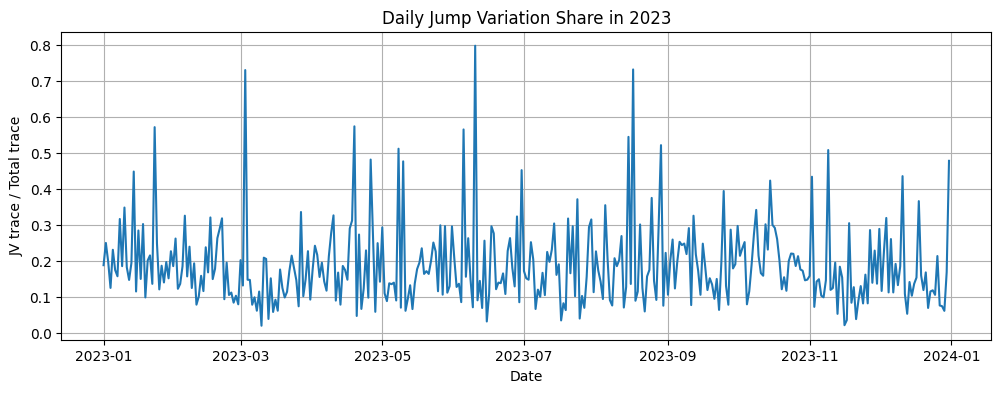

In [18]:
jv_2023 = jv_share_df[jv_share_df["year"] == 2023]

plt.figure(figsize=(12, 4))
plt.plot(jv_2023["date"], jv_2023["jv_share"])
plt.title("Daily Jump Variation Share in 2023")
plt.xlabel("Date")
plt.ylabel("JV trace / Total trace")
plt.grid(True)
plt.show()

# Jump Check (2025-10-10)

In [19]:
# 점프가 큰 날 찾기. 2025-10-10: 전체의 94%가 점프
jv_share_df.sort_values("gamma_untrunc_trace", ascending=False).head(20)

,date,gamma_trunc_trace,gamma_untrunc_trace,jv_trace,jv_share,year
1012,2025-10-10,8.804164,103.682765,94.878602,0.915086,2025
763,2025-02-03,3.598502,6.104612,2.506110,0.410527,2025
366,2024-01-03,1.860178,5.443657,3.583479,0.658285,2024
467,2024-04-13,2.704058,5.305005,2.600947,0.490282,2024
159,2023-06-10,0.898824,4.433753,3.534929,0.797277,2023
581,2024-08-05,3.782443,4.296360,0.513917,0.119617,2024
466,2024-04-12,1.331600,3.828981,2.497381,0.652231,2024
707,2024-12-09,2.336805,3.467957,1.131152,0.326172,2024
428,2024-03-05,2.528135,3.406219,0.878084,0.257789,2024
832,2025-04-13,1.443573,2.957529,1.513956,0.511899,2025


In [20]:
# 특정 날짜의 점프가 전체 점프에서 40%나 차지함.
total_untrunc_sum = jv_share_df["gamma_untrunc_trace"].sum()
total_jv_sum = jv_share_df["jv_trace"].sum()

top_day = jv_share_df.loc[jv_share_df["gamma_untrunc_trace"].idxmax()]

print("Top date:", top_day["date"])
print("Top day share in total untrunc:",
      top_day["gamma_untrunc_trace"] / total_untrunc_sum)

print("Top day share in total JV:",
      top_day["jv_trace"] / total_jv_sum)

Top date: 2025-10-10 00:00:00
Top day share in total untrunc: 0.13337013460731695
Top day share in total JV: 0.44243843731326216


In [21]:
# e^2.451 = 10.6 --> 1min에 +1060% or -91.4% 수준의 가격 변화 --> liquidity crash, data artifact 가능성
target_day = pd.Timestamp("2025-10-10")

df_day = log_price_panel.loc[
    log_price_panel.index.normalize() == target_day
].copy()

ret_day = df_day.diff().dropna()

print("shape:", df_day.shape)
print("NaN cells:", df_day.isna().sum().sum())

abs_ret = ret_day.abs()

print("Max abs 1-min log return:")
display(abs_ret.max().sort_values(ascending=False).head(10))

print("Number of 1-min returns above 10%:")
display((abs_ret > 0.10).sum().sort_values(ascending=False).head(10))

print("Number of 1-min returns above 20%:")
display((abs_ret > 0.20).sum().sort_values(ascending=False).head(10))

shape: (1440, 200)
NaN cells: 0
Max abs 1-min log return:


DEGOUSDT     2.451005
KAVAUSDT     1.477083
IOTXUSDT     1.420900
OGNUSDT      0.980829
ONEUSDT      0.758716
GMXUSDT      0.719465
FORTHUSDT    0.699827
DFUSDT       0.668837
LDOUSDT      0.627098
C98USDT      0.608068
dtype: float32

Number of 1-min returns above 10%:


OSMOUSDT     19
IOTXUSDT     18
CHESSUSDT    18
KAVAUSDT     17
HOOKUSDT     16
PHBUSDT      15
FILUSDT      14
DEGOUSDT     14
WOOUSDT      13
CVXUSDT      13
dtype: int64

Number of 1-min returns above 20%:


KAVAUSDT     12
IOTXUSDT     12
GMXUSDT       7
AVAXUSDT      7
DEGOUSDT      7
CHESSUSDT     7
DFUSDT        6
PHBUSDT       6
FXSUSDT       6
CVXUSDT       5
dtype: int64

In [22]:
# 특정 날짜에 몇몇 코인들의 경우 97%, 93% ... 등 대부분이 점프로 분류됨
target_day = pd.Timestamp("2025-10-10")

idx = jv_share_df.index[jv_share_df["date"] == target_day][0]

gamma_untrunc_diag = np.diag(Gamma_untrunc_raw_array[idx])
gamma_trunc_diag = np.diag(Gamma_trunc_raw_array[idx])
jv_diag = np.diag(JV_raw_array[idx])

asset_contrib_1010 = pd.DataFrame({
    "ticker": log_price_panel.columns,
    "gamma_untrunc_diag": gamma_untrunc_diag,
    "gamma_trunc_diag": gamma_trunc_diag,
    "jv_diag": jv_diag,
})

asset_contrib_1010["jv_share_diag"] = (
    asset_contrib_1010["jv_diag"]
    / asset_contrib_1010["gamma_untrunc_diag"]
)

asset_contrib_1010["untrunc_weight"] = (
    asset_contrib_1010["gamma_untrunc_diag"]
    / asset_contrib_1010["gamma_untrunc_diag"].sum()
)

asset_contrib_1010["jv_weight"] = (
    asset_contrib_1010["jv_diag"]
    / asset_contrib_1010["jv_diag"].sum()
)

display(
    asset_contrib_1010
    .sort_values("gamma_untrunc_diag", ascending=False)
    .head(10)
)

,ticker,gamma_untrunc_diag,gamma_trunc_diag,jv_diag,jv_share_diag,untrunc_weight,jv_weight
58,KAVAUSDT,3.506657,0.098589,3.408068,0.971885,0.033821,0.035920
90,IOTXUSDT,3.455265,0.081753,3.373512,0.976340,0.033325,0.035556
164,DEGOUSDT,2.693879,0.171008,2.522871,0.936520,0.025982,0.026591
43,DYDXUSDT,1.755637,0.113858,1.641779,0.935147,0.016933,0.017304
30,HOOKUSDT,1.723064,0.122315,1.600749,0.929013,0.016619,0.016872
38,ONEUSDT,1.544840,0.086986,1.457854,0.943692,0.014900,0.015365
157,CHESSUSDT,1.515822,0.142064,1.373757,0.906279,0.014620,0.014479
194,AVAUSDT,1.497394,0.082322,1.415072,0.945023,0.014442,0.014915
141,PHAUSDT,1.370171,0.052617,1.317555,0.961599,0.013215,0.013887
152,CVXUSDT,1.317908,0.116988,1.200920,0.911232,0.012711,0.012657


In [23]:
# 특정 날짜만 제외하면 점프가 정상 수준으로 들어옴
df_excl_1010 = jv_share_df[
    jv_share_df["date"] != pd.Timestamp("2025-10-10")
].copy()

summary_excl_1010 = jump_share_summary(df_excl_1010)

print("All days:")
print("mean daily   :", summary_all["mean_daily_jv_share"] * 100)
print("median daily :", summary_all["median_daily_jv_share"] * 100)
print("aggregate    :", summary_all["aggregate_jv_share"] * 100)

print("\nExcluding 2025-10-10:")
print("mean daily   :", summary_excl_1010["mean_daily_jv_share"] * 100)
print("median daily :", summary_excl_1010["median_daily_jv_share"] * 100)
print("aggregate    :", summary_excl_1010["aggregate_jv_share"] * 100)

All days:
mean daily   : 14.78407356313223
median daily : 12.14369737409803
aggregate    : 27.584647842902637

Excluding 2025-10-10:
mean daily   : 14.713941494721059
median daily : 12.124823386724318
aggregate    : 17.747068237122406


## Figure 2: log kurtosis

In [24]:
def compute_figure2_log_kurtosis(Gamma_array: np.ndarray) -> dict:

    # 1. 입력 확인
    if Gamma_array.ndim != 3:
        raise ValueError(f"Gamma_array must be 3D, got shape {Gamma_array.shape}")

    T, p, p2 = Gamma_array.shape

    # 2. 각 날짜별 Gamma 대각성분 추출
    # daily_variances[t, i] = t일 i번째 자산의 PRVM variance
    daily_variances = np.array([
        np.diag(Gamma_array[t])
        for t in range(T)
    ])

    # 3. 각 자산별 kurtosis 계산
    # axis=0: 날짜 방향으로 각 자산별 kurtosis 계산
    raw_kurtoses = stats.kurtosis(
        daily_variances,
        axis=0,
        fisher=False,
        bias=False,
        nan_policy="omit"
    )

    # 4. 로그 변환 전 안전장치
    raw_kurtoses = np.where(raw_kurtoses > 0, raw_kurtoses, np.nan)

    log_kurtoses = np.log(raw_kurtoses)
    log_kurtoses = log_kurtoses[np.isfinite(log_kurtoses)]

    if len(log_kurtoses) == 0:
        raise ValueError("No valid log-kurtosis values.")

    # 5. 기준선: t-distribution with df=5
    ref_kurtosis = 9.0
    ref_log_kurtosis = np.log(ref_kurtosis)

    result = {
        "daily_variances": daily_variances,
        "raw_kurtoses": raw_kurtoses,
        "log_kurtoses": log_kurtoses,
        "ref_kurtosis": ref_kurtosis,
        "ref_log_kurtosis": ref_log_kurtosis,
        "T": T,
        "p": p,
    }

    return result

In [25]:
fig2_result = compute_figure2_log_kurtosis(Gamma_trunc_psd_array)

log_kurtoses = fig2_result["log_kurtoses"]
ref_log_kurtosis = fig2_result["ref_log_kurtosis"]

print("T:", fig2_result["T"])
print("p:", fig2_result["p"])

print(f"Reference Log Kurtosis (t_5): {ref_log_kurtosis:.4f}")
print(f"Sample Mean Log Kurtosis    : {np.mean(log_kurtoses):.4f}")
print(f"Sample Median Log Kurtosis  : {np.median(log_kurtoses):.4f}")
print(f"Min Log Kurtosis            : {np.min(log_kurtoses):.4f}")
print(f"Max Log Kurtosis            : {np.max(log_kurtoses):.4f}")

T: 1095
p: 200
Reference Log Kurtosis (t_5): 2.1972
Sample Mean Log Kurtosis    : 4.7540
Sample Median Log Kurtosis  : 4.6777
Min Log Kurtosis            : 2.9131
Max Log Kurtosis            : 6.8145


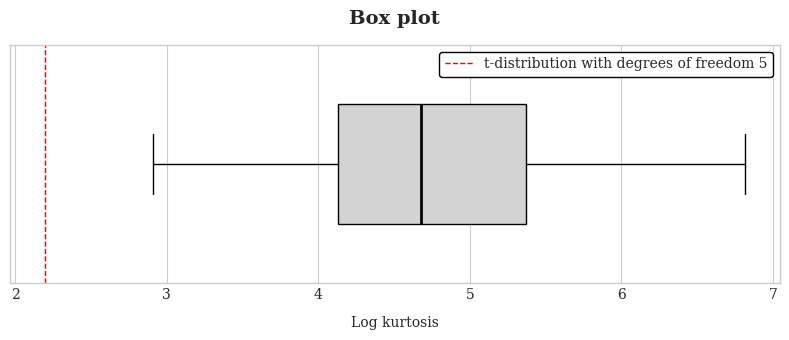

In [26]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "serif"

plt.figure(figsize=(8, 3.5))

box = plt.boxplot(
    log_kurtoses,
    vert=False,
    patch_artist=True,
    widths=0.5
)

for patch in box["boxes"]:
    patch.set_facecolor("lightgray")
    patch.set_edgecolor("black")

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

plt.axvline(
    ref_log_kurtosis,
    color="red",
    linestyle="--",
    linewidth=1,
    label="t-distribution with degrees of freedom 5"
)

plt.title("Box plot", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Log kurtosis", labelpad=10)
plt.yticks([])

plt.legend(
    frameon=True,
    framealpha=1,
    edgecolor="black",
    loc="upper right"
)

plt.tight_layout()
plt.show()

## Figure7: Eigen gap check

In [27]:
def idiosyncratic_matrix(Gd: np.ndarray, r: int) -> np.ndarray:

    Gd = 0.5 * (Gd + Gd.T)
    w, V = la.eigh(Gd)
    idx = np.argsort(w)[::-1]
    w = w[idx]
    V = V[:, idx]

    if r <= 0:
        Gi = Gd.copy()
    else:
        Wf = w[:r]
        Vf = V[:, :r]

        factor_part = (Vf * Wf) @ Vf.T
        Gi = Gd - factor_part

    Gi = 0.5 * (Gi + Gi.T)

    return Gi

def compute_figure7_eigen_gap(
    Gamma_array: np.ndarray,
    r_hat: int = 3,
    max_k: int = 100,
) -> dict:

    if Gamma_array.ndim != 3:
        raise ValueError(f"Gamma_array must be 3D, got shape {Gamma_array.shape}")

    T, p, p2 = Gamma_array.shape

    if max_k >= p:
        max_k = p - 1

    print(f"Computing Figure 7 eigen gaps")
    print(f"T = {T}, p = {p}, r_hat = {r_hat}, max_k = {max_k}")

    # 1. 날짜별 idiosyncratic matrix 계산
    Gi_list = []

    for t in range(T):
        Gi_t = idiosyncratic_matrix(Gamma_array[t], r=r_hat)
        Gi_list.append(Gi_t)

    # 2. average idiosyncratic estimator
    Gi_bar = np.mean(Gi_list, axis=0)
    Gi_bar = 0.5 * (Gi_bar + Gi_bar.T)

    # 3. eigenvalues of average idiosyncratic matrix
    w, _ = la.eigh(Gi_bar)
    w = np.sort(w)[::-1]

    # 4. eigen gaps
    gaps = w[:max_k] - w[1:max_k + 1]
    x = np.arange(1, max_k + 1)

    result = {
        "Gi_bar": Gi_bar,
        "eigenvalues": w,
        "gaps": gaps,
        "x": x,
        "T": T,
        "p": p,
        "r_hat": r_hat,
        "max_k": max_k,
    }

    return result

In [28]:
fig7_result = compute_figure7_eigen_gap(
    Gamma_array=Gamma_trunc_psd_array,
    r_hat=3,        # 1이 적합 (May be bitcoin)
    max_k=100,
)

x = fig7_result["x"]
gaps = fig7_result["gaps"]
eigenvalues = fig7_result["eigenvalues"]

print("Gi_bar shape:", fig7_result["Gi_bar"].shape)
print("Number of eigenvalues:", len(eigenvalues))

print("Top 10 eigenvalues:")
print(eigenvalues[:10])

print("Top 10 eigen gaps:")
print(gaps[:10])

Computing Figure 7 eigen gaps
T = 1095, p = 200, r_hat = 3, max_k = 100
Gi_bar shape: (200, 200)
Number of eigenvalues: 200
Top 10 eigenvalues:
[0.00265771 0.00245884 0.00203624 0.00200878 0.00190713 0.00185917
 0.00182599 0.00181621 0.00173646 0.00171062]
Top 10 eigen gaps:
[1.98869020e-04 4.22603839e-04 2.74581482e-05 1.01652223e-04
 4.79629472e-05 3.31806466e-05 9.77819242e-06 7.97424807e-05
 2.58461006e-05 4.51373671e-05]


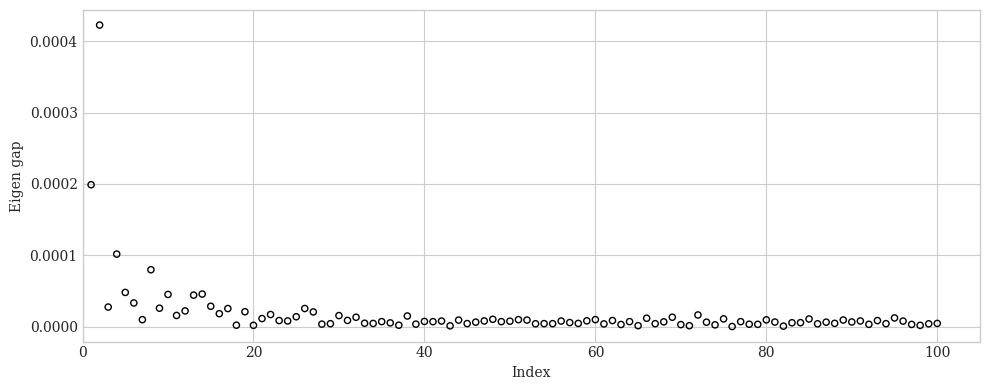

In [29]:
plt.figure(figsize=(10, 4))

plt.scatter(
    x,
    gaps,
    facecolors="none",
    edgecolors="black",
    s=20
)

plt.xlabel("Index")
plt.ylabel("Eigen gap")
plt.xlim(0, fig7_result["max_k"] + 5)

plt.tight_layout()
plt.show()

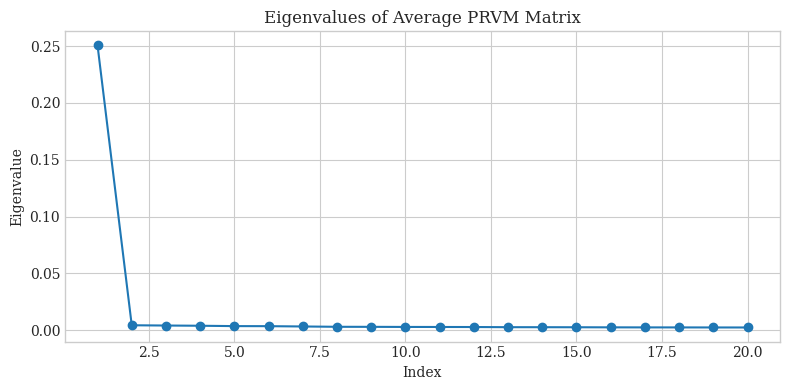

In [30]:
# Eigen value
Gamma_bar = Gamma_trunc_psd_array.mean(axis=0)
Gamma_bar = 0.5 * (Gamma_bar + Gamma_bar.T)

w, _ = la.eigh(Gamma_bar)
w = np.sort(w)[::-1]

max_k = 20
x = np.arange(1, max_k + 1)

plt.figure(figsize=(8, 4))
plt.plot(x, w[:max_k], marker="o")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of Average PRVM Matrix")
plt.tight_layout()
plt.show()

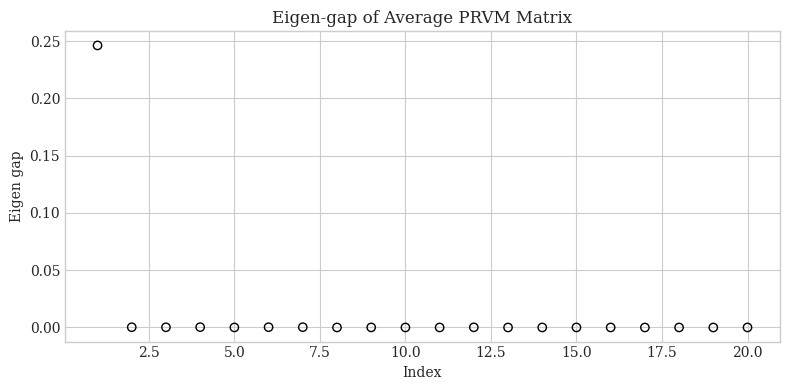

In [31]:
# Gap of eigen value
gaps = w[:max_k] - w[1:max_k + 1]

plt.figure(figsize=(8, 4))
plt.scatter(x, gaps, facecolors="none", edgecolors="black")
plt.xlabel("Index")
plt.ylabel("Eigen gap")
plt.title("Eigen-gap of Average PRVM Matrix")
plt.tight_layout()
plt.show()

# PRVM check : select 'r'

In [32]:
def compute_daily_eigvals_from_PRVM(
    PRVM,
    psd_projection=False,
    psd_eps=1e-10,
    verbose=True
):

    T, p, _ = PRVM.shape
    eigvals_all = np.empty((T, p), dtype=np.float64)

    iterator = range(T)
    if verbose:
        iterator = tqdm(iterator, desc="Computing daily eigenvalues")

    for d in iterator:
        G = 0.5 * (PRVM[d] + PRVM[d].T)

        if psd_projection:
            w, V = la.eigh(G)
            w = np.maximum(w, psd_eps)
            G = (V * w) @ V.T

        w = la.eigvalsh(G)      # ascending
        eigvals_all[d] = w[::-1]  # descending

    return eigvals_all

def estimate_fivar_rank_one_window_from_eigvals(
    eigvals_window,
    m=1440,
    r_max=30,
    c2=0.5
):

    window_n, p = eigvals_window.shape

    # c1 = 0.02 * average 30th eigenvalue within this window
    c1 = 0.02 * np.mean(eigvals_window[:, r_max - 1])

    penalty_base = np.sqrt(np.log(p) / np.sqrt(m)) + np.log(p) / p
    penalty_common = penalty_base ** c2

    js = np.arange(1, r_max + 1)
    criteria = np.empty(r_max, dtype=np.float64)

    for idx, j in enumerate(js):
        eigen_part = np.sum(eigvals_window[:, j - 1] / p)
        penalty_part = window_n * j * c1 * penalty_common
        criteria[idx] = eigen_part + penalty_part

    j_star = js[np.argmin(criteria)]
    r_hat = int(j_star - 1)

    result = {
        "r_hat": r_hat,
        "j_star": int(j_star),
        "criteria": criteria,
        "c1": c1,
        "penalty_base": penalty_base,
        "penalty_common": penalty_common,
        "window_n": window_n,
        "p": p,
        "m": m,
        "r_max": r_max,
    }

    return r_hat, result

def rolling_estimate_fivar_rank_from_PRVM(
    PRVM,
    window_n=365,
    m=1440,
    r_max=30,
    c2=0.5,
    step=1,
    psd_projection=False,
    psd_eps=1e-10,
    verbose=True
):

    T, p, _ = PRVM.shape

    if verbose:
        print(f"Total PRVM days T = {T}")
        print(f"p = {p}")
        print(f"m = {m}")
        print(f"Rolling window_n = {window_n}")
        print(f"r_max = {r_max}")
        print(f"step = {step}")

    # Step 1. 전체 기간 eigenvalue를 한 번만 계산
    eigvals_all = compute_daily_eigvals_from_PRVM(
        PRVM=PRVM,
        psd_projection=psd_projection,
        psd_eps=psd_eps,
        verbose=verbose
    )

    records = []
    rank_results = []

    iterator = range(0, T - window_n + 1, step)
    if verbose:
        iterator = tqdm(iterator, desc="Rolling rank estimation")

    for start in iterator:
        end = start + window_n

        eigvals_window = eigvals_all[start:end]

        r_hat, result = estimate_fivar_rank_one_window_from_eigvals(
            eigvals_window=eigvals_window,
            m=m,
            r_max=r_max,
            c2=c2
        )

        records.append({
            "window_start_idx": start,
            "window_end_idx": end - 1,
            "window_n": window_n,
            "r_hat": r_hat,
            "j_star": result["j_star"],
            "c1": result["c1"],
            "criterion_min": np.min(result["criteria"]),
        })

        rank_results.append(result)

    rank_df = pd.DataFrame(records)

    if verbose:
        print("\nRank frequency:")
        print(rank_df["r_hat"].value_counts().sort_index())

        print("\nSummary:")
        print(rank_df["r_hat"].describe())

    return rank_df, rank_results, eigvals_all

In [33]:
PRVM = Gamma_trunc_psd_array

rank_df, rank_results, eigvals_all = rolling_estimate_fivar_rank_from_PRVM(
    PRVM=PRVM,
    window_n=365,
    m=1440,
    r_max=30,
    c2=0.5,
    step=1, # rolling window 몇일씩 이동
    psd_projection=False,
    verbose=True
)

Total PRVM days T = 1095
p = 200
m = 1440
Rolling window_n = 365
r_max = 30
step = 1


Rolling rank estimation: 100%|██████████| 731/731 [00:00<00:00, 9240.00it/s]


Rank frequency:
r_hat
3    731
Name: count, dtype: int64

Summary:
count    731.0
mean       3.0
std        0.0
min        3.0
25%        3.0
50%        3.0
75%        3.0
max        3.0
Name: r_hat, dtype: float64


In [34]:
print(rank_df.head())
print(rank_df.tail())

print(rank_df["r_hat"].value_counts().sort_index())

   window_start_idx  window_end_idx  window_n  r_hat  j_star        c1  \
0                 0             364       365      3       4  0.000040   
1                 1             365       365      3       4  0.000040   
2                 2             366       365      3       4  0.000040   
3                 3             367       365      3       4  0.000041   
4                 4             368       365      3       4  0.000041   

   criterion_min  
0       0.067007  
1       0.067178  
2       0.067691  
3       0.068009  
4       0.068302  
     window_start_idx  window_end_idx  window_n  r_hat  j_star        c1  \
726               726            1090       365      3       4  0.000032   
727               727            1091       365      3       4  0.000032   
728               728            1092       365      3       4  0.000032   
729               729            1093       365      3       4  0.000032   
730               730            1094       365      3       

In [35]:
unique_r, counts = np.unique(rank_df["r_hat"], return_counts=True)

for r, c in zip(unique_r, counts):
    print(f"r = {r}: {c} steps")

r = 3: 731 steps
